In [1]:
# The %pip command installs the driver directly into the running Jupyter kernel
%pip install clickhouse-connect

import clickhouse_connect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to ClickHouse via Docker Desktop's built-in bridge!
client = clickhouse_connect.get_client(
    host='host.docker.internal', 
    port=8123, 
    username='admin', 
    password='secretpassword',
    database='telemetry'
)

query = "SELECT * FROM daily_event_summary ORDER BY event_date ASC"
df = client.query_df(query)

print(f"Successfully loaded {len(df)} rows into memory!")
display(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
Successfully loaded 5 rows into memory!


,event_date,event_type,total_events,unique_users
0,2026-04-21,k8s_stateful_test,1,1
1,2026-04-21,grafana_spike_test,50,1
2,2026-04-22,prometheus_metrics_test,20,1
3,2026-04-22,distributed_trace_test,2,1
4,2026-04-23,stream_spam_test,40,1


/tmp/ipykernel_627/4216151232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


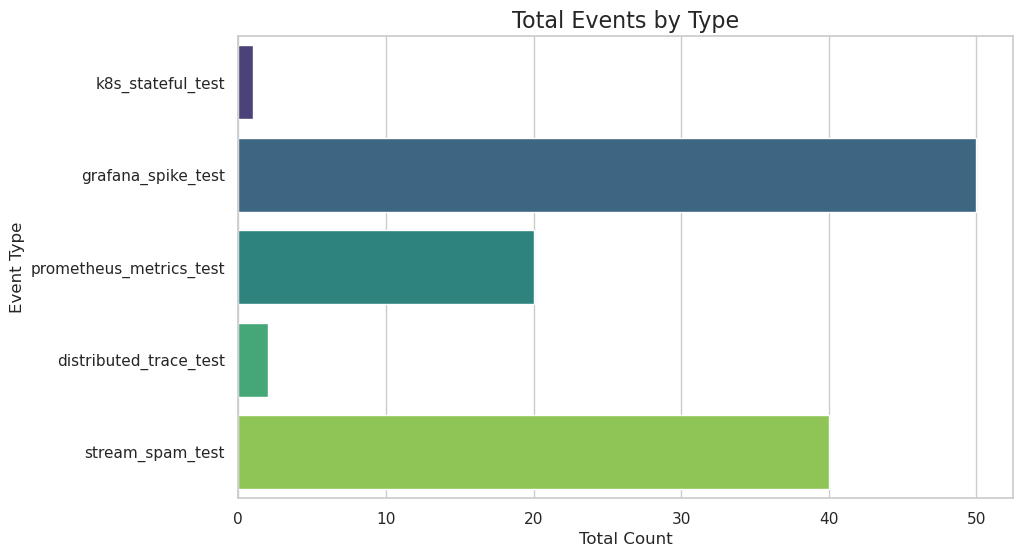

In [2]:
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a bar plot grouping the total events by event_type
barplot = sns.barplot(
    data=df, 
    x="total_events", 
    y="event_type", 
    palette="viridis",
    errorbar=None
)

plt.title("Total Events by Type", fontsize=16)
plt.xlabel("Total Count", fontsize=12)
plt.ylabel("Event Type", fontsize=12)

# Display the chart
plt.show()

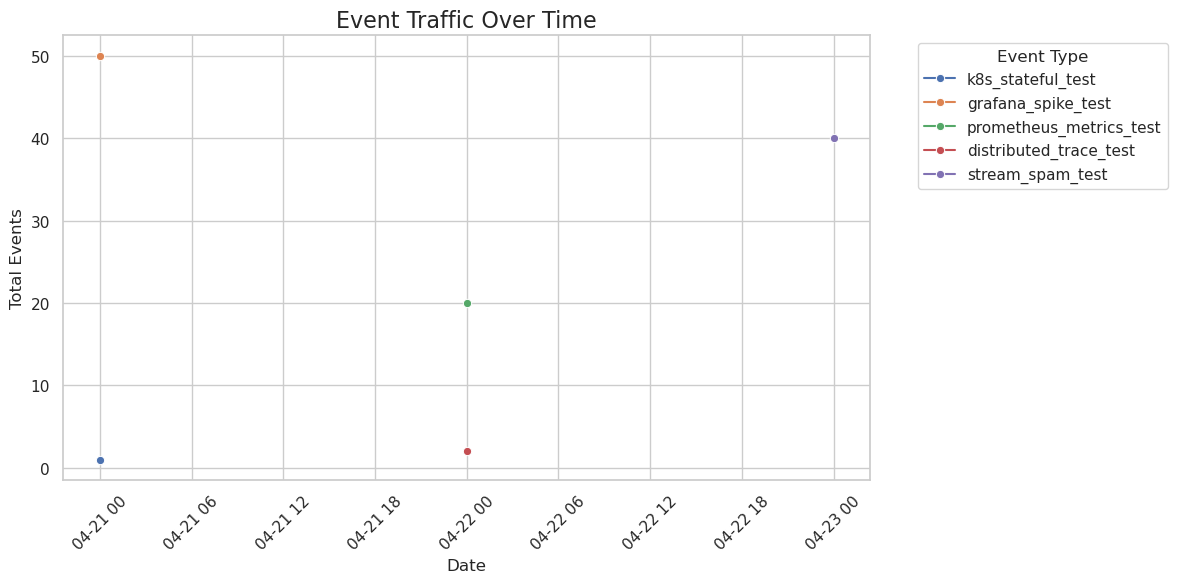

In [3]:
plt.figure(figsize=(12, 6))

# Create a line plot showing traffic over time
lineplot = sns.lineplot(
    data=df,
    x="event_date",
    y="total_events",
    hue="event_type",
    marker="o"
)

plt.title("Event Traffic Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Events", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Event Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()